<a href="https://colab.research.google.com/github/jahnavitelsang/DATASCIENCE/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Decision tree

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('/content/sales.csv')

In [4]:
df.head()

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,Bad,42,17,Yes,Yes,yes
1,2,111,48,16,260,83,Good,65,10,Yes,Yes,yes
2,3,113,35,10,269,80,Medium,59,12,Yes,Yes,yes
3,4,117,100,4,466,97,Medium,55,14,Yes,Yes,no
4,5,141,64,3,340,128,Bad,38,13,Yes,No,no


In [5]:
#separate the numerial and categorical rows

In [6]:
x_cont = df.iloc[:,[1,2,3,4,5,7,8]]
x_cont.head()

#can also use df.iloc[:,np.r[1:6, 7:9]]

,CompPrice,Income,Advertising,Population,Price,Age,Education
0,138,73,11,276,120,42,17
1,111,48,16,260,83,65,10
2,113,35,10,269,80,59,12
3,117,100,4,466,97,55,14
4,141,64,3,340,128,38,13


In [7]:
y_cont = df.loc[:,['ShelveLoc','Urban','US','high']]
y_cont.head()

,ShelveLoc,Urban,US,high
0,Bad,Yes,Yes,yes
1,Good,Yes,Yes,yes
2,Medium,Yes,Yes,yes
3,Medium,Yes,Yes,no
4,Bad,Yes,No,no


In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
SS = StandardScaler()
x_cont_numerical = df.iloc[:,[1,2,3,4,5,7,8]]
SS_X = SS.fit_transform(x_cont_numerical)
SS_X = pd.DataFrame(SS_X, columns=x_cont_numerical.columns)
SS_X.head()
SS.X_cont = list(df.iloc[:,[1,2,3,4,5,7,8]])
SS_X.head()



,CompPrice,Income,Advertising,Population,Price,Age,Education
0,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,1.184449
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,-1.490113
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,-0.725953
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,0.038208
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,-0.343872


In [10]:
#now convert the categories into numbers

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
LE = LabelEncoder()

In [13]:
df['ShelveLoc'] = LE.fit_transform(df['ShelveLoc'])
df['Urban'] = LE.fit_transform(df['Urban'])
df['US'] = LE.fit_transform(df['US'])
df['high'] = LE.fit_transform(df['high'])
df.head()

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,0,42,17,1,1,1
1,2,111,48,16,260,83,1,65,10,1,1,1
2,3,113,35,10,269,80,2,59,12,1,1,1
3,4,117,100,4,466,97,2,55,14,1,1,0
4,5,141,64,3,340,128,0,38,13,1,0,0


In [14]:
y_cont = df.loc[:,['ShelveLoc','Urban','US','high']]
y_cont.head()

,ShelveLoc,Urban,US,high
0,0,1,1,1
1,1,1,1,1
2,2,1,1,1
3,2,1,1,0
4,0,1,0,0


In [15]:
df_new = pd.concat([SS_X,y_cont], axis=1)
df_new.head()

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc,Urban,US,high
0,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,1.184449,0,1,1,1
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,-1.490113,1,1,1,1
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,-0.725953,2,1,1,1
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,0.038208,2,1,1,0
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,-0.343872,0,1,0,0


In [16]:
#data partision
Y = df_new['high']
X = df_new.drop(['high'], axis=1)
X


,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc,Urban,US
0,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,1.184449,0,1,1
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,-1.490113,1,1,1
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,-0.725953,2,1,1
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,0.038208,2,1,1
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,-0.343872,0,1,0
...,...,...,...,...,...,...,...,...,...,...
395,0.850455,1.407551,1.560513,-0.420131,0.516132,-1.256023,0.038208,1,1,1
396,0.915749,-1.633482,-0.547271,-1.547909,0.177823,0.103677,-1.108033,2,0,1
397,2.417512,-1.526151,0.807733,0.700853,1.827078,-0.823391,1.566529,2,1,1
398,-1.630719,0.370022,0.054953,0.130170,-0.879391,-0.205346,-0.725953,0,1,1


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=100)

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
DT = DecisionTreeClassifier()
DT.fit(X_train, Y_train)

DecisionTreeClassifier()

In [21]:
y_pred_train = y_pred = DT.predict(X_train)
y_pred_test = y_pred = DT.predict(X_test)


In [22]:
from sklearn.metrics import accuracy_score, log_loss

In [23]:
accuracy_score_train = accuracy_score(Y_train, y_pred_train)
accuracy_score_test = accuracy_score(Y_test, y_pred_test)
accuracy_score_train, accuracy_score_test

(1.0, 0.725)

In [24]:
training_loss = log_loss(Y_train, y_pred_train)
test_loss = log_loss(Y_test, y_pred_test)
training_loss, test_loss

(2.2204460492503136e-16, 9.912004682007217)

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
model = DecisionTreeClassifier(criterion='gini')

In [27]:
#set up a shuffle split
from sklearn.model_selection import ShuffleSplit, cross_validate, cross_val_score

In [28]:
shuffle_split = ShuffleSplit(n_splits=10, test_size=0.3, random_state=100)

In [29]:
#apply cross val
cv_results = cross_validate(model, X, Y, cv=shuffle_split, scoring='accuracy',return_train_score=True)

#return_train_score=True: By default, cross-validation only looks at the test scores. Setting this to True tells Pandas to also save the model's accuracy on the training chunks so you can compare the two and check for overfitting.

In [30]:
train_results = cv_results['train_score']
test_results = cv_results['test_score']

In [31]:
np.round(train_results.mean(),2)

np.float64(1.0)

In [32]:
np.round(test_results.mean(),2)

np.float64(0.75)

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


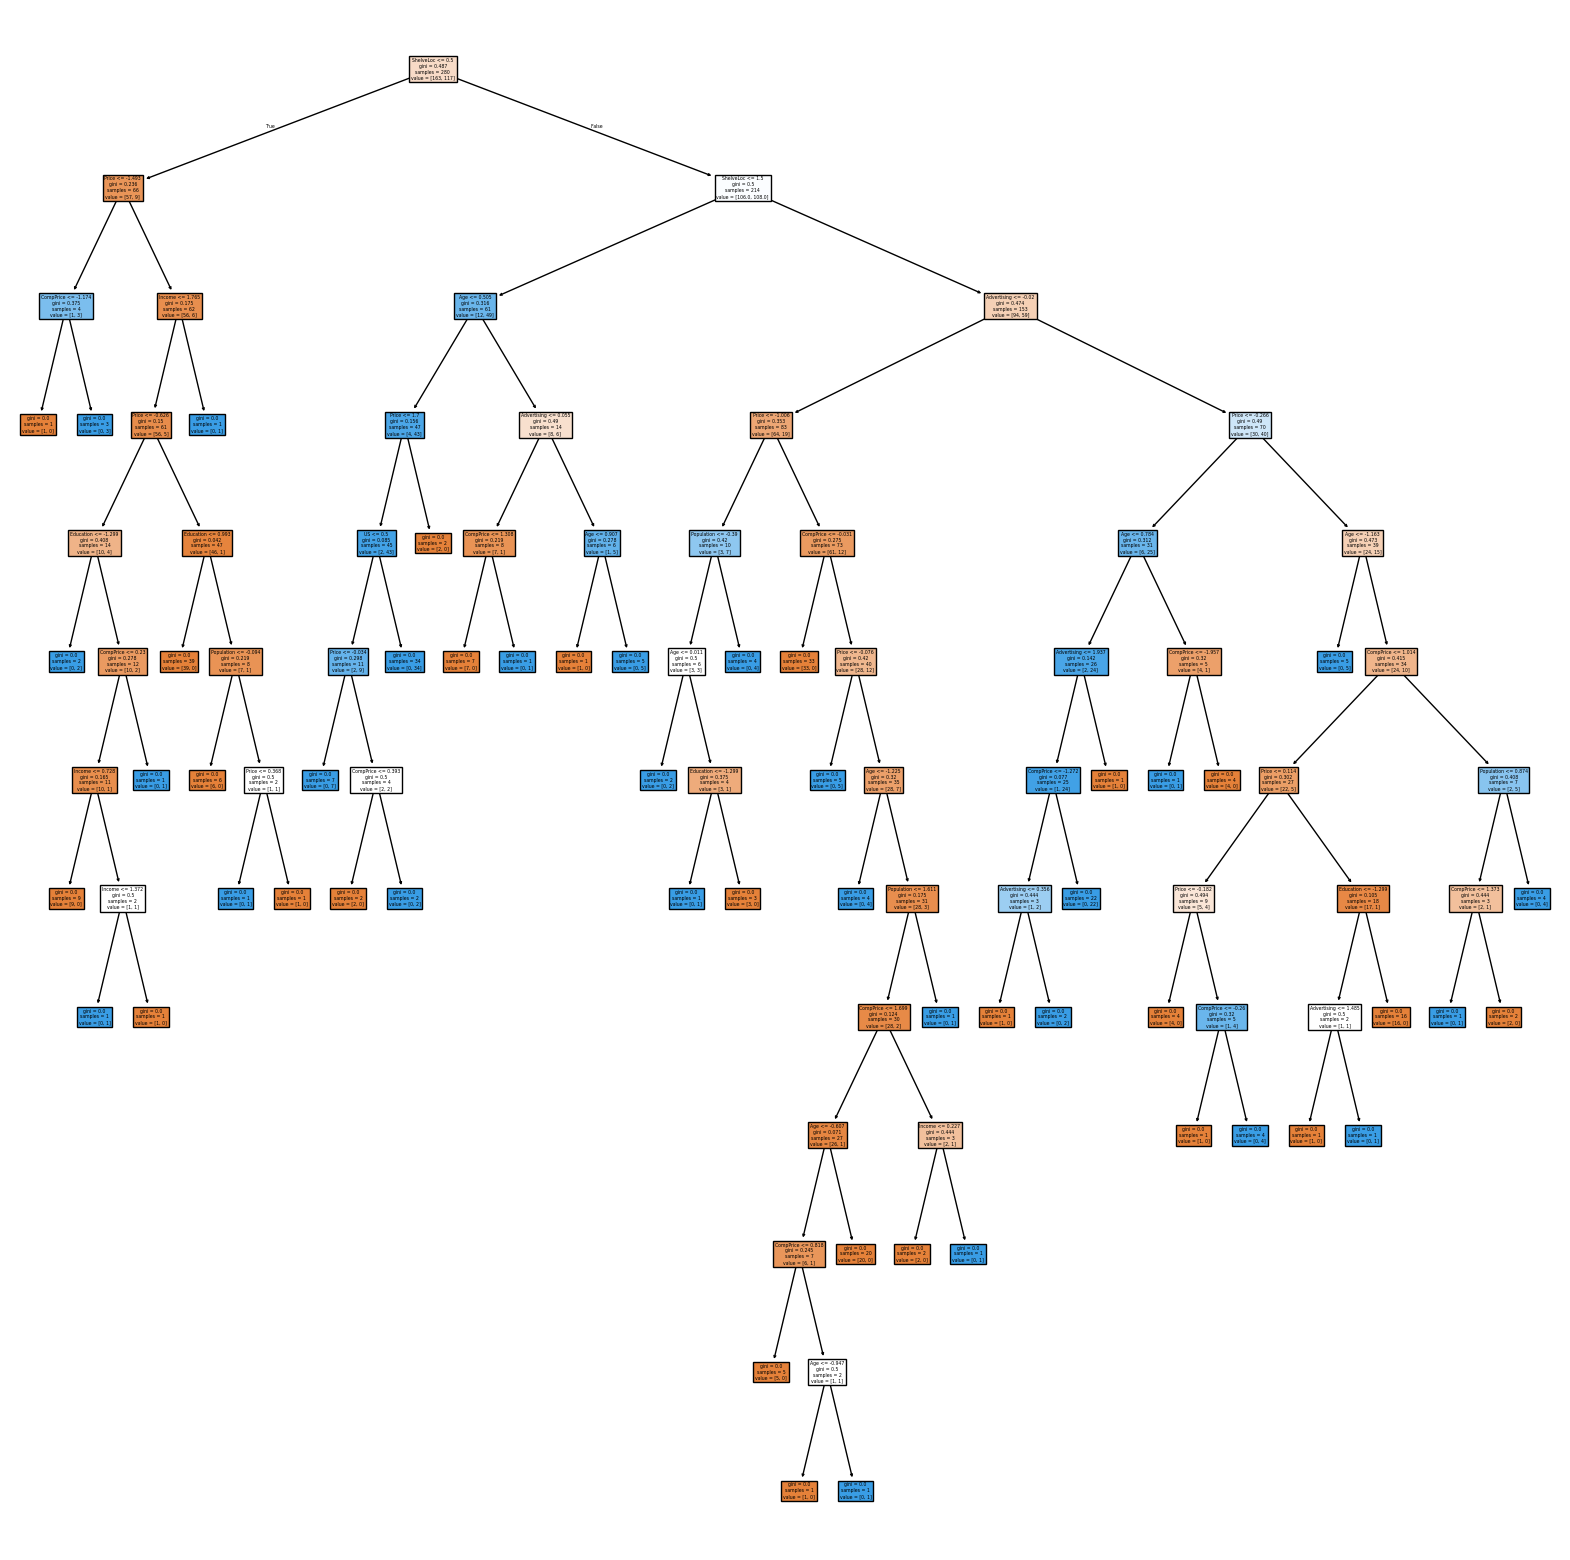

In [34]:
plt.figure(figsize = (20,20))
plot_tree(DT, filled=True, feature_names=X.columns)
plt.show()

In [35]:
#Esembling techniques

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
#Initialize the model. estimators is no of decision tree

In [38]:
rf_model = RandomForestClassifier(n_estimators = 100,random_state=42 ,max_samples=0.8 , max_features=0.8,max_depth=5)

In [39]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(max_depth=5, max_features=0.8, max_samples=0.8,
                       random_state=42)

In [40]:
y_pred_train_rf = y_pred = rf_model.predict(X_train)
y_pred_test_rf = y_pred = rf_model.predict(X_test)

In [41]:
training_accuracy = accuracy_score(Y_train, y_pred_train_rf)
test_accuracy = accuracy_score(Y_test, y_pred_test_rf)
training_accuracy, test_accuracy

(0.9642857142857143, 0.8333333333333334)

In [42]:
training_loss = log_loss(Y_train, y_pred_train_rf)
test_loss = log_loss(Y_test, y_pred_test_rf)
training_loss, test_loss

(1.2872733353256127, 6.007275564852859)

In [43]:
# using grid search cv, write down some combinations of trees

In [44]:
from sklearn.model_selection import GridSearchCV

In [45]:
param_grid = {
    'n_estimators':[50,100,200],
    'max_samples':[0.6,0.7,0.8],
    'max_features':[0.6,0.7,0.8]
}

In [46]:
rf_model = RandomForestClassifier(random_state=42,max_depth = 10)

In [47]:
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy')

In [48]:
grid_search.fit(X_train, Y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_depth=10, random_state=42),
             param_grid={'max_features': [0.6, 0.7, 0.8],
                         'max_samples': [0.6, 0.7, 0.8],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [49]:
#print best hyperparameter and its scores
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Hyperparameters: {'max_features': 0.6, 'max_samples': 0.6, 'n_estimators': 100}
Best Accuracy: 0.8035714285714286


In [49]:
#GRADIENT BOOSTING

In [50]:
from sklearn.ensemble import GradientBoostingClassifier

In [51]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

In [52]:
gb_model.fit(X_train, Y_train)

GradientBoostingClassifier(random_state=42)

In [53]:
y_pred_train_gb = gb_model.predict(X_train)
y_pred_test_gb = gb_model.predict(X_test)

In [55]:
training_accuracy_gb = accuracy_score(Y_train, y_pred_train_gb)
test_accuracy_gb = accuracy_score(Y_test, y_pred_test_gb)
training_accuracy_gb , test_accuracy_gb

(0.9964285714285714, 0.8583333333333333)

In [56]:
training_loss_gb = log_loss(Y_train, y_pred_train_gb)
test_loss_gb = log_loss(Y_test, y_pred_test_gb)
training_loss_gb , test_loss_gb

(0.1287273335325615, 5.10618423012493)

In [ ]:
#now go ahead wuth the grid search

In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
param_grid = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.1,1,10],
    'max_depth':[3,4,5]
}

In [60]:
gb_model = GradientBoostingClassifier(random_state=42)

In [61]:
grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=5, scoring='accuracy')

In [62]:
grid_search.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.01, 0.1, 1, 10],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [63]:
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Hyperparameters: {'learning_rate': 1, 'max_depth': 3, 'n_estimators': 100}
Best Accuracy: 0.8607142857142858


In [ ]:
#Now evalutae on the test dataset (not mandatory)

In [64]:
best_gb_model = grid_search.best_estimator_
y_pred_test_best_gb = best_gb_model.predict(X_test)
test_accuracy_best_gb = accuracy_score(Y_test, y_pred_test_best_gb)
test_accuracy_best_gb


0.7916666666666666

In [65]:
test_loss_gb = log_loss(Y_test, y_pred_test_best_gb)
test_loss_gbf

7.509094456066074

In [ ]:
#ADA BOOST

In [66]:
from sklearn.ensemble import AdaBoostClassifier

In [67]:
ada_model = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

In [69]:
ada_model.fit(X_train, Y_train)

AdaBoostClassifier(learning_rate=0.1, n_estimators=100, random_state=42)

In [70]:
y_pred_ada_train = ada_model.predict(X_train)
y_pred_ada_test = ada_model.predict(X_test)

In [71]:
training_accuracy_ada = accuracy_score(Y_train, y_pred_ada_train)
test_accuracy_ada = accuracy_score(Y_test, y_pred_ada_test)
training_accuracy_ada , test_accuracy_ada

(0.8, 0.75)

In [72]:
training_loss_ada = log_loss(Y_train, y_pred_ada_train)
test_loss_ada = log_loss(Y_test, y_pred_ada_test)
training_loss_ada , test_loss_ada

(7.20873067782343, 9.010913347279288)

In [73]:
from sklearn.model_selection import GridSearchCV

In [74]:
param_grid = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.1,1,10]
}

In [75]:
ada_model = AdaBoostClassifier(random_state=42)

In [76]:
grid_search = GridSearchCV(estimator=ada_model, param_grid=param_grid, cv=5, scoring='accuracy')

In [77]:
grid_search.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42),
             param_grid={'learning_rate': [0.01, 0.1, 1, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [78]:
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Hyperparameters: {'learning_rate': 1, 'n_estimators': 100}
Best Accuracy: 0.9


In [ ]:
#evaluate o test data

In [79]:
best_ada_model = grid_search.best_estimator_
y_pred_test_best_ada = best_ada_model.predict(X_test)
test_accuracy_best_ada = accuracy_score(Y_test, y_pred_test_best_ada)
test_accuracy_best_ada

0.8583333333333333

In [80]:
test_loss_best_ada = log_loss(Y_test, y_pred_test_best_ada)
test_loss_best_ada

5.10618423012493